In [3]:
# pip install wordcloud

In [1]:
from elasticsearch import Elasticsearch
import pandas as pd
import json
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
import warnings
import urllib3
import time
import requests
import numpy as np
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress only InsecureRequestWarning from urllib3 (for verify_certs=False)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# === API Parameter ===
api_url = "http://localhost:9090/api/youtubeelectionapi"

# === Define two ranges to avoid 10,000 limit ===
ranges = [
    {"start": "2024-03-01", "end": "2025-03-20"},
    {"start": "2025-03-21", "end": "2026-01-01"}
]

# === Fetch & Combine ===
all_data = []

for i, params in enumerate(ranges):
    response = requests.get(api_url, params=params)
    if response.status_code == 200:
        json_data = response.json()
        results = json_data.get("data", [])
        print(f"[OK] Retrieved {len(results)} documents from range {i+1}")
        all_data.append(pd.DataFrame(results))
    else:
        print(f"[X] Request {i+1} failed with status code {response.status_code}")

# === Combine & Clean ===
if all_data:
    yte_df_raw = pd.concat(all_data, ignore_index=True)
    print(f"[✓] Combined total: {len(yte_df_raw)} rows.")
    display(yte_df_raw.columns)
else:
    print("[X] No data retrieved from any range.")

[OK] Retrieved 3424 documents from range 1
[OK] Retrieved 9557 documents from range 2
[✓] Combined total: 12981 rows.


Index(['snippet', 'search_prompt', 'kind', 'etag', 'id', 'contentDetails',
       'statistics'],
      dtype='object')

In [2]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import time

# Normalize raw data
yte_df = pd.json_normalize(yte_df_raw.to_dict(orient='records'))

# Ensure numeric types for relevant fields
for field in ['statistics.viewCount', 'statistics.likeCount', 'statistics.commentCount', 'statistics.favoriteCount']:
    yte_df[field] = yte_df[field].astype(float)

# Parse and localize datetime
yte_df['snippet.publishedAt'] = pd.to_datetime(yte_df['snippet.publishedAt'], utc=True)
yte_df['published_melbourne'] = yte_df['snippet.publishedAt'].dt.tz_convert('Australia/Melbourne')

# Calculate hours since posted using datetime difference
now = pd.Timestamp.now(tz='UTC')
yte_df['hours_since_post'] = (now - yte_df['snippet.publishedAt']).dt.total_seconds() / 3600

# Compute raw weighted score
yte_df['raw_score'] = (
    yte_df['statistics.viewCount'] * 0.5 +
    yte_df['statistics.likeCount'] * 1.0 +
    yte_df['statistics.commentCount'] * 1.5 +
    yte_df['statistics.favoriteCount'] * 1.2
)

# Exponential decay (freshness factor)
yte_df['decay'] = np.exp(-0.05 * yte_df['hours_since_post'] / 24)

# Hotness score = raw * decay
yte_df['score1'] = yte_df['raw_score'] * yte_df['decay']

# Engagement score per view
yte_df['statistics.viewCount'] = yte_df['statistics.viewCount'].replace(0, 1)  # Avoid div-by-zero
yte_df['score2'] = (
    (yte_df['statistics.likeCount'] / yte_df['statistics.viewCount']) +
    2 * (yte_df['statistics.commentCount'] / yte_df['statistics.viewCount']) +
    3 * (yte_df['statistics.favoriteCount'] / yte_df['statistics.viewCount'])
) * 100

# Clean up invalid values
yte_df[['score1', 'score2']] = yte_df[['score1', 'score2']].replace([np.inf, -np.inf], np.nan).fillna(0)



# Scale to [1, 100]
def clip_and_scale(series, feature_range=(1, 100)):
    lower = series.quantile(0.05)
    upper = series.quantile(0.95)
    clipped = series.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

def log_clip_scale(series, feature_range=(1, 100)):
    log_vals = np.log1p(series)  # log(1 + x) 防止 log(0)
    lower = log_vals.quantile(0.05)
    upper = log_vals.quantile(0.95)
    clipped = log_vals.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

yte_df['score1_scaled'] = log_clip_scale(yte_df['score1'])
# score1_log = np.log1p(yte_df['score1'])
# yte_df['score1_scaled'] = scaler.fit_transform(score1_log.values.reshape(-1, 1))
yte_df['score2_scaled'] = clip_and_scale(yte_df['score2'])

# Optional: print info
print("[OK] DataFrame processed. Available columns:")
print(yte_df.columns.tolist())
yte_df.head()


[OK] DataFrame processed. Available columns:
['search_prompt', 'kind', 'etag', 'id', 'snippet.publishedAt', 'snippet.description', 'snippet.title', 'snippet.channelId', 'snippet.categoryId', 'snippet.channelTitle', 'snippet.tags', 'snippet.liveBroadcastContent', 'contentDetails.duration', 'contentDetails.definition', 'contentDetails.dimension', 'statistics.likeCount', 'statistics.viewCount', 'statistics.favoriteCount', 'statistics.commentCount', 'published_melbourne', 'hours_since_post', 'raw_score', 'decay', 'score1', 'score2', 'score1_scaled', 'score2_scaled']


,search_prompt,kind,etag,id,snippet.publishedAt,snippet.description,snippet.title,snippet.channelId,snippet.categoryId,snippet.channelTitle,...,statistics.favoriteCount,statistics.commentCount,published_melbourne,hours_since_post,raw_score,decay,score1,score2,score1_scaled,score2_scaled
0,australia election,youtube#video,hIP9z_zhkxSmlfO5UVoXA7pB8WI,9LkLBQ8qHL4,2024-11-01 02:11:16+00:00,Sky News host Rita Panahi reacts to Kamala Har...,Lefties losing it: Kamala Harris and Tim Walz ...,UCO0akufu9MOzyz3nvGIXAAw,25,Sky News Australia,...,0.0,3764.0,2024-11-01 13:11:16+11:00,4735.199330,297294.5,0.000052,15.448006,4.969307,30.505703,32.443326
1,australia election,youtube#video,VSSzqeGQevLD9mL3DfuMZmteP6E,8LbmwgL-_Pg,2024-11-01 02:36:07+00:00,#news #video #australia #world #youtube #subsc...,How does the Electoral College work?,UCi-nUi67HVFEtpaFsjRj_NA,25,The Sydney Morning Herald and The Age,...,0.0,0.0,2024-11-01 13:36:07+11:00,4734.785163,467.0,0.000052,0.024287,2.120536,1.252855,14.417705
2,australia election,youtube#video,sU4mtObQmFO2zs6wIVKQJU1BCds,6tKHnK4qvNQ,2024-11-01 02:58:38+00:00,KPMG Australia Partner and Chief Economist Dr ...,Analysis: US election outcome could cause impl...,UCO0akufu9MOzyz3nvGIXAAw,25,Sky News Australia,...,0.0,36.0,2024-11-01 13:58:38+11:00,4734.409886,1575.5,0.000052,0.082001,3.635140,1.830440,24.001373
3,australia election,youtube#video,XKzHjyTqXLa4uOYj9MXK1IipNKw,wel9fwHYd8s,2024-11-01 04:06:21+00:00,"With the upcoming US elections, let's talk abo...",America vs. Australia: Elections and Election ...,UCZ9GEKI080s5c2XaGaNMa_g,19,Kinda Australian,...,0.0,514.0,2024-11-01 15:06:21+11:00,4733.281275,7921.5,0.000052,0.413265,13.188596,4.644768,84.450939
4,australia election,youtube#video,XLQ5v_UOt8x1ArpFkC0hsmP9byI,W301_ObQ9TM,2024-11-01 04:30:33+00:00,"With the US election just days away, on the Au...",The mainstream push back against the elites an...,UC0VXp0q5i8o-CxL_8Q3HOtQ,25,Institute of Public Affairs,...,0.0,14.0,2024-11-01 15:30:33+11:00,4732.877941,8071.0,0.000052,0.421418,1.498151,4.705383,10.479563


In [3]:
import ipywidgets as widgets

# Get min and max dates in local (Melbourne) time
start_date_actual = yte_df['published_melbourne'].min().date()
end_date_actual = yte_df['published_melbourne'].max().date()

# Generate full date range list for slider
date_range = pd.date_range(start=start_date_actual, end=end_date_actual, freq='D')
date_slider = widgets.SelectionRangeSlider(
    options=[d.strftime("%Y-%m-%d") for d in date_range],
    index=(0, len(date_range) - 1),
    description='Date Range:',
    orientation='horizontal',
    layout={'width': '100%'}
)

# Frequency resolution dropdown
resolution = widgets.Dropdown(
    options=[('Hourly', 'H'), ('Every 3 Hours', '3H'), ('Daily', 'D'), ('Weekly', 'W')],
    value='H',
    description='Resolution:'
)

# Combine controls into a UI layout
ui = widgets.VBox([date_slider, resolution])

# Plotting function triggered by widget updates
def update_all_plots(date_range, freq):
    start_str, end_str = date_range
    # Localize start and end to Melbourne timezone to match the DataFrame
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")


    # Filter DataFrame based on selected date range
    yte_df_filtered = yte_df[(yte_df['published_melbourne'] >= start) & (yte_df['published_melbourne'] <= end)]

    if yte_df_filtered.empty:
        print("No data for selected range.")
        return

    # Set time column as index for resampling
    yte_df_tmp = yte_df_filtered.set_index('published_melbourne')

    # Resample metrics
    resampled_count = yte_df_tmp.resample(freq).size()
    resampled_views = yte_df_tmp['statistics.viewCount'].resample(freq).sum()
    resampled_score1 = yte_df_tmp['score1'].resample(freq).mean()
    resampled_score2 = yte_df_tmp['score2'].resample(freq).mean()

    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    axs[0].plot(resampled_count.index, resampled_count.values, marker='o')
    axs[0].set_title(f'Number of Uploaded Videos ({freq} resolution)')
    axs[0].set_ylabel("Upload Count")
    axs[0].grid(True)

    axs[1].plot(resampled_views.index, resampled_views.values, marker='o', color='green')
    axs[1].set_title(f'Total View Count ({freq} resolution)')
    axs[1].set_ylabel("Total Views")
    axs[1].grid(True)

    axs[2].plot(resampled_score1.index, resampled_score1.values, marker='o', color='red')
    axs[2].set_title(f'Average Score1 Over Time ({freq} resolution)')
    axs[2].set_ylabel("Average Score1")
    axs[2].grid(True)

    axs[3].plot(resampled_score2.index, resampled_score2.values, marker='o', color='orange')
    axs[3].set_title(f'Average Score2 Over Time ({freq} resolution)')
    axs[3].set_ylabel("Average Score2")
    axs[3].grid(True)

    for ax in axs:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Connect the UI widgets to the plotting function
out_all = widgets.interactive_output(update_all_plots, {
    'date_range': date_slider,
    'freq': resolution
})

# Display the full UI and output
display(ui, out_all)


Output()

In [4]:
# Convert to datetime if needed
yte_df['published_melbourne'] = pd.to_datetime(yte_df['published_melbourne'])

# Filter: between Jan and Feb 2025
mask = (yte_df['published_melbourne'] >= '2025-01-01') & (yte_df['published_melbourne'] < '2025-05-01')

# Sort by original score1
anomaly = yte_df.loc[mask].sort_values(by='statistics.viewCount', ascending=False).head(3)

print(anomaly[['snippet.title', 'id']])



                                          snippet.title           id
1424   What's the taste Lay’s? #squidgame #snacks #lays  23dgL1To_z4
1590  अनंत अंबानी ने बुर्ज खलीफा खरीद लिया | Anant A...  MNRfc6zxX1M
2044  #Yt#shotrs  Aggressive moment#rohitsharma #vir...  JuMI9WCDiJ8


In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def extract_text(row):
    text = row.get('snippet.title', '') + " " + row.get('snippet.description', '')
    tags = row.get('snippet.tags', [])
    if isinstance(tags, list):
        text += " " + " ".join(tags)
    return text

yte_df['text'] = yte_df.apply(extract_text, axis=1)

from wordcloud import STOPWORDS
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # Remove links
    text = re.sub(r'[^\w\s]', '', text)      # Remove punctuation
    return text

yte_df['clean_text'] = yte_df['text'].fillna('').apply(clean_text)



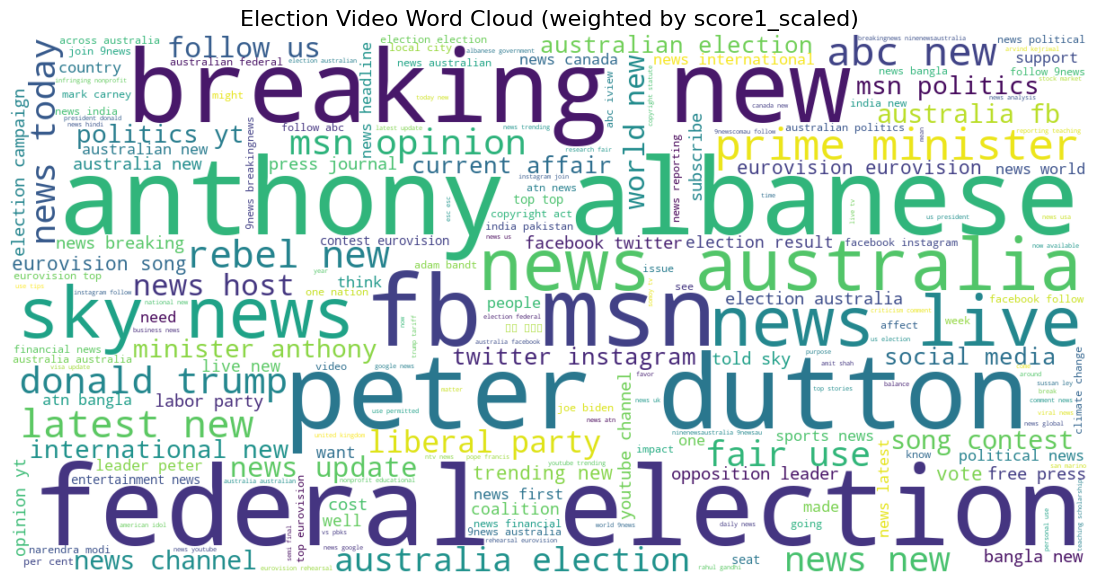

In [5]:
def weighted_text(row, weight_col='score1_scaled'):
    weight = int(row[weight_col] // 10) 
    return (row['clean_text'] + ' ') * max(1, weight)

yte_df['weighted_text'] = yte_df.apply(weighted_text, axis=1)
combined_text = ' '.join(yte_df['weighted_text'])
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=200
).generate(combined_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Election Video Word Cloud (weighted by score1_scaled)", fontsize=16)
plt.show()
